### Agency-level regression: **our predictors vs. the existing model** (adjusted R²)

Goal is to measure how **adjusted R²** moves when we move from original predictor set -> smaller predictor set
because of Ohio DoI issues -> *our* new BG predictor set.

- **Target:** severity-weighted total agency crime rate `wtotal_pt_m` (each of the 7 primary
  crimes contributes 1/7 of its national-relative rate, rescaled by the national
  violent+property level — the same weighted-rate construct as our BG `compute_weighted_scores`).
- **Harness (identical for both models):** population-weighted `RidgeCV` on `log1p(rate)`
  (`TransformedTargetRegressor`), standardized predictors, a single random 75/25 train/test
  split over agencies with `population ≥ 1,000` and complete predictors in **both** sets.
- **Baseline:** 2 parts: `original_predictors` (22 demographic/ACS/geo features), and `approved_predictors`read straight from `ct_muni_df.sav`.
- **Ours:** our BG predictor set (demographics + property + imagery + POI) **rolled up to
  agency level** via a population-weighted block-group→agency crosswalk, plus ACS commute-mode
  **transit proxies** (`bus_pct`, `train_pct`) — transit's national stand-in, since we lack a
  national GTFS feed.

- Used `docs/business_context/crime_ct_models_revised.ipynb` (the model being reproduced for reference)
- Our roll-up functions are in `src/regression_modelling/data_wrangling/agency.py`
- TODO: Predictions from existing model:
    - gs://geospatial-projects/location_inc/ns4/2025q4/block_group_data.sav
    - Most important columns are 'bg_key' and 'total_pt_ct'. The latter is the predicted weighted total crime rate where "ct" stands for "current" not census tract. 

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))

from regression_modelling.data_wrangling.agency import (
    build_wtotal_target, rollup_predictors_to_agency, load_transit_proxies,
    adjusted_r2, get_gcs_fs, read_sav_from_gcs,
)
from crime_blockgroup_mapping.constants import GCS_ROOT, UCR_YEAR
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

#### 1. Load the agency dataset and build the weighted target

`ct_muni_df.sav` is our national census-tract × agency table (already carries the
z-scored baseline predictors and per-crime agency rates). `build_wtotal_target` adds `wtotal_pt_m`.

In [2]:
fs = get_gcs_fs()
ct_muni_df, _ = read_sav_from_gcs(f"{GCS_ROOT}/crime/{UCR_YEAR}/ct_muni_df.sav", fs)
print("ct_muni_df:", ct_muni_df.shape)

ct_muni_df = build_wtotal_target(ct_muni_df, fs)
print("wtotal_pt_m built; non-null:", ct_muni_df["wtotal_pt_m"].notna().sum())

ct_muni_df: (388848, 88)


wtotal_pt_m built; non-null: 388848


In [3]:
# Examine ct_muni_df
ct_muni_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 388848 entries, 0 to 388847
Data columns (total 99 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   akey                    388848 non-null  str    
 1   year                    388848 non-null  float64
 2   ct_key                  388848 non-null  str    
 3   name                    388848 non-null  str    
 4   popest                  388848 non-null  float64
 5   lat                     388848 non-null  float64
 6   lon                     388848 non-null  float64
 7   sqmi                    388842 non-null  float64
 8   population_acs          387018 non-null  float64
 9   incarc_pct              388839 non-null  float64
 10  pr                      388848 non-null  float64
 11  vi                      388848 non-null  float64
 12  midatlantic             388848 non-null  float64
 13  encentral               388848 non-null  float64
 14  southatlantic           388848 

#### 2. Assemble the predictor matrices — three baselines + ours

The existing national model is stripped in **two governance stages**, giving three baselines:

- **`original_predictors` (22)** — the full pre-governance agency model.
- **`approved_predictors` (18)** — `original` minus the **4 internal-team-flagged** demographics
  (`grandkids`, `married`, `nonfam`, `singleparent`).
- **`dept_approved_predictors` (10)** — `original` minus **all 12 Department-disallowed** variables
  (the 4 above + job density, real-estate tax, school-quality index, unemployment,
  home-value-per-room, college enrollment, dorms, gini). This is what the Department will actually let ship.

The adjusted-R² **decay 22 → 18 → 10** is the governance cost we aim to refill with *our* new
predictors (population-weighted BG roll-up + ACS transit proxies, attached to `primary_place == 1`).

In [4]:
# --- baseline predictor sets: the existing national model, progressively stripped by governance ---
# ORIGINAL (22)      = full pre-governance model.
# APPROVED (18)      = original minus the 4 internal-team-flagged demographics.
# DEPT-APPROVED (10) = original minus ALL 12 Department-disallowed variables (superset of the 4).
# The adj-R2 decay 22 -> 18 -> 10 is the governance cost our new predictors aim to refill.
original_predictors = ['zlg10_pop_est_5mile','zlg10_jobs_5min','zin_household_pct','zcol_pct',
    'zsqrt_moved1yr_pct','zsqrt_vacant_pct','zlg10_job_density','zgini_index','zcity_centers_dist',
    'zmrpct_val_rm','encentral','zusrpct_total_sc','zsqrt_md_retax','zdet_pct','southatlantic',
    'zlg10_dorms_pct','midatlantic','zsqrt_unemp_pct',
    # internal-team-flagged (proxy / robustness concerns), present in the original model:
    'zlg10_grandkids_pct','zmarried_pct','znonfam_pct','zsqrt_singleparent_pct']

# internal team flag (4): household-composition demographics
flagged_variables = ['zlg10_grandkids_pct','zmarried_pct','znonfam_pct','zsqrt_singleparent_pct']
approved_predictors = [p for p in original_predictors if p not in set(flagged_variables)]

# Department-disallowed (12) = the 4 above + 8 more: job density, real-estate tax, school-quality
# index (usrpct_total_sc), unemployment, home-value-per-room (mrpct_val_rm), college enrollment,
# college dorms, gini index.
dept_disallowed = ['zlg10_grandkids_pct','zmarried_pct','znonfam_pct','zsqrt_singleparent_pct',
    'zlg10_job_density','zsqrt_md_retax','zusrpct_total_sc','zsqrt_unemp_pct',
    'zmrpct_val_rm','zcol_pct','zlg10_dorms_pct','zgini_index']
dept_approved_predictors = [p for p in original_predictors if p not in set(dept_disallowed)]

# --- our predictor set: rolled-up BG predictors + ACS transit proxies ---
agency_pred = rollup_predictors_to_agency()  # pop_est_5mile -> pop_est_5mile_log (ADR 0006)
transit = load_transit_proxies()
ours = agency_pred.join(transit, how="left")
our_predictors = list(agency_pred.columns) + list(transit.columns)
print(f"baselines -> original: {len(original_predictors)} | approved: {len(approved_predictors)} "
      f"| dept-approved: {len(dept_approved_predictors)} | ours: {len(our_predictors)} predictors")
print("internal-flagged (4):", flagged_variables)
print("dept-approved (kept):", dept_approved_predictors)

baselines -> original: 22 | approved: 18 | dept-approved: 10 | ours: 21 predictors
internal-flagged (4): ['zlg10_grandkids_pct', 'zmarried_pct', 'znonfam_pct', 'zsqrt_singleparent_pct']
dept-approved (kept): ['zlg10_pop_est_5mile', 'zlg10_jobs_5min', 'zin_household_pct', 'zsqrt_moved1yr_pct', 'zsqrt_vacant_pct', 'zcity_centers_dist', 'encentral', 'zdet_pct', 'southatlantic', 'midatlantic']


In [5]:
# Examine predictors rolled up to agency level
ours.info()

<class 'pandas.DataFrame'>
Index: 13599 entries, ABBEVILLE_AL to ZUMBROTA_MN
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   moved1yr_pct                   13599 non-null  float64
 1   own_pct                        13599 non-null  float64
 2   lap_pct                        13599 non-null  float64
 3   city_centers_dist              13598 non-null  float64
 4   pop_ch_1mile                   13598 non-null  float64
 5   unq_convenience_stores_clips   13589 non-null  Float64
 6   unq_gas_stations_clips         13589 non-null  Float64
 7   unq_liquor_stores_clips        13589 non-null  Float64
 8   roof_condition_avg             13555 non-null  float64
 9   roof_debris_pct_avg            13549 non-null  float64
 10  hardscapes_pct_avg             13548 non-null  float64
 11  roof_missing_material_pct      13549 non-null  float64
 12  vacant_pct_log                 13511 non-null

In [6]:
# agency-level rows, join our predictors on akey
muni = ct_muni_df[ct_muni_df["primary_place"] == 1].copy().set_index("akey")
muni = muni.join(ours, how="left")
print("agency rows:", muni.shape)
print("coverage of our predictors (non-null share):")
print((muni[our_predictors].notna().mean().sort_values()).round(3).to_string())

agency rows: (13945, 119)
coverage of our predictors (non-null share):
clip_foreclosure_pct_lag6_log    0.985
clip_liens_pct_lag6_log          0.985
vacant_pct_lag6_log              0.985
vacant_pct_log                   0.993
hardscapes_pct_avg               0.996
roof_debris_pct_avg              0.996
roof_missing_material_pct        0.996
roof_condition_avg               0.996
clip_foreclosure_pct_log         0.999
clip_liens_pct_log               0.999
unq_liquor_stores_clips          0.999
unq_convenience_stores_clips     0.999
unq_gas_stations_clips           0.999
bus_pct                          1.000
train_pct                        1.000
city_centers_dist                1.000
pop_est_5mile_log                1.000
pop_ch_1mile                     1.000
own_pct                          1.000
lap_pct                          1.000
moved1yr_pct                     1.000


In [7]:
# Examine distributions
def describe_cols(df, cols):
    d = df[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    d["skew"] = df[cols].skew()
    d["n_missing"] = df[cols].isna().sum()
    d["pct_missing"] = (df[cols].isna().mean() * 100).round(1)
    return d.round(2)

def plot_grid(df, cols, title, bins=40, color="steelblue"):
    ncol = 3
    nrow = int(np.ceil(len(cols) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna(), bins=bins, color=color, edgecolor="white")
        ax.set_title(c); ax.set_ylabel("Agencies")
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=13, y=1.02); fig.tight_layout(); plt.show()

In [8]:
# Examine zeroes and percentiles
predictors = ["train_pct",
              "bus_pct",
              "city_centers_dist"
              ]
display(describe_cols(muni, predictors))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
train_pct,13939.0,0.44,1.88,0.00,0.00,0.00,0.00,0.00,0.01,2.27,8.88,38.53,8.39,6,0.0
bus_pct,13939.0,0.65,1.65,0.00,0.00,0.00,0.00,0.05,0.59,3.04,7.21,33.33,6.82,6,0.0
city_centers_dist,13942.0,36.09,15.67,3.27,6.96,9.61,20.04,46.10,50.00,50.00,50.00,50.00,-0.53,3,0.0


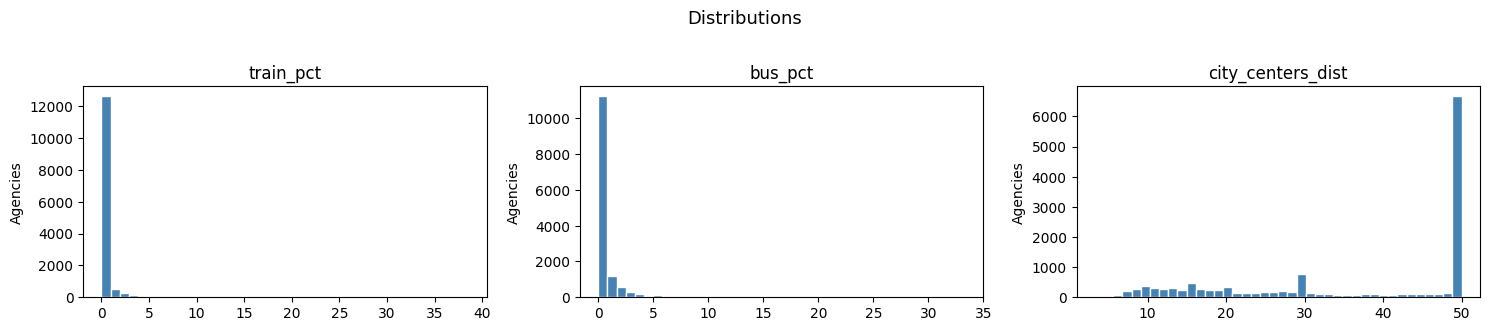

In [9]:
# distribution plots
plot_grid(muni, predictors, "Distributions")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
bus_pct_log,13939.0,0.32,0.50,0.0,0.0,0.0,0.0,0.05,0.46,1.40,2.11,3.54,2.09,6,0.0
train_pct_log,13939.0,0.17,0.46,0.0,0.0,0.0,0.0,0.00,0.01,1.18,2.29,3.68,3.51,6,0.0
has_transit,13945.0,0.58,0.49,0.0,0.0,0.0,0.0,1.00,1.00,1.00,1.00,1.00,-0.32,0,0.0


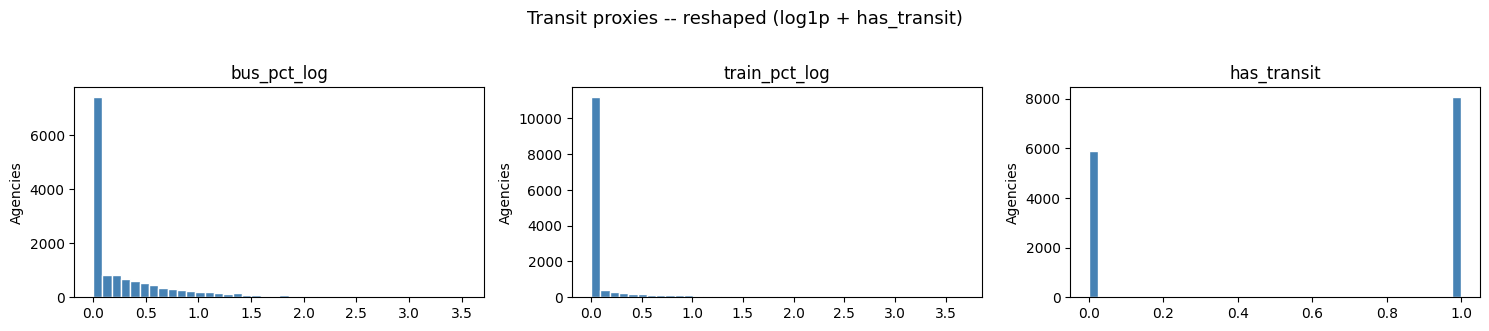

ours_experiments: 22 predictors
['moved1yr_pct', 'own_pct', 'lap_pct', 'city_centers_dist', 'pop_ch_1mile', 'unq_convenience_stores_clips', 'unq_gas_stations_clips', 'unq_liquor_stores_clips', 'roof_condition_avg', 'roof_debris_pct_avg', 'hardscapes_pct_avg', 'roof_missing_material_pct', 'vacant_pct_log', 'clip_liens_pct_log', 'clip_foreclosure_pct_log', 'vacant_pct_lag6_log', 'clip_liens_pct_lag6_log', 'clip_foreclosure_pct_lag6_log', 'pop_est_5mile_log', 'bus_pct_log', 'train_pct_log', 'has_transit']


In [10]:
# --- experiment: reshape the ACS transit proxies (heavy zeros, right skew) ---
# has_transit: 1 if either commute-mode share is non-zero (57% of agencies), else 0.
muni["has_transit"] = ((muni["bus_pct"] > 0) | (muni["train_pct"] > 0)).astype(int)
# log1p compresses the right skew (0-100 pct scale) while preserving the zeros.
muni["bus_pct_log"] = np.log1p(muni["bus_pct"])
muni["train_pct_log"] = np.log1p(muni["train_pct"])

transit_shaped = ["bus_pct_log", "train_pct_log", "has_transit"]
display(describe_cols(muni, transit_shaped))
plot_grid(muni, transit_shaped, "Transit proxies -- reshaped (log1p + has_transit)")

# experimental 'ours' set: swap the raw transit pair for the reshaped versions.
# EXPAND THIS as we try more feature-shape experiments (extra cols must exist in muni).
ours_experiments = [p for p in our_predictors if p not in ("bus_pct", "train_pct")] + transit_shaped
print("ours_experiments:", len(ours_experiments), "predictors")
print(ours_experiments)

#### 3. Common modeling set + single train/test split

To compare fairly, both models use the **same agencies** — those with `population ≥ 1,000`,
a valid `wtotal_pt_m`, and complete predictors in **both** sets — and the **same** 75/25 split.

In [11]:
pop_cut = 1000
# fair common set: complete on the ORIGINAL baseline (superset of approved) AND our set
complete = (muni["wtotal_pt_m"].notna()
            & (muni["population_m"] >= pop_cut)
            & muni[original_predictors].notna().all(axis=1)
            & muni[our_predictors].notna().all(axis=1))
model_df = muni[complete].copy()
print(f"common modeling set: {len(model_df):,} agencies "
      f"(pop-weighted mean wtotal rate {np.average(model_df['wtotal_pt_m'], weights=model_df['population_m']):.2f})")

train_df, test_df = train_test_split(model_df, random_state=99999)
print("train:", len(train_df), "| test:", len(test_df))

common modeling set: 12,573 agencies (pop-weighted mean wtotal rate 20.91)
train: 9429 | test: 3144


#### 4. Harness (identical for both predictor sets)

Population-weighted `RidgeCV` on `log1p(wtotal_pt_m)` with standardized predictors. Reports
population-weighted R²/MAE (train & test) plus **adjusted R²** on the test set.

In [12]:
def fit_agency(predictors, label):
    scaler = StandardScaler().fit(train_df[predictors])
    Xtr = scaler.transform(train_df[predictors]); Xte = scaler.transform(test_df[predictors])
    ytr, yte = train_df["wtotal_pt_m"].values, test_df["wtotal_pt_m"].values
    wtr, wte = train_df["population_m"].values, test_df["population_m"].values

    model = TransformedTargetRegressor(regressor=RidgeCV(), func=np.log1p, inverse_func=np.expm1)
    model.fit(Xtr, ytr, sample_weight=wtr)
    ptr, pte = model.predict(Xtr), model.predict(Xte)

    r2_tr = r2_score(ytr, ptr, sample_weight=wtr)
    r2_te = r2_score(yte, pte, sample_weight=wte)
    row = dict(model=label, n_predictors=len(predictors),
               n_train=len(ytr), n_test=len(yte),
               R2_train=round(r2_tr, 3), R2_test=round(r2_te, 3),
               adjR2_test=round(adjusted_r2(r2_te, len(yte), len(predictors)), 3),
               MAE_train=round(mean_absolute_error(ytr, ptr, sample_weight=wtr), 3),
               MAE_test=round(mean_absolute_error(yte, pte, sample_weight=wte), 3))
    return model, row, pte

In [13]:
# three baselines (original -> approved -> dept-approved) trace the governance decay; then
# ours-only, ours+reshaped transit, the deployable dept-approved + ours model, and its
# parsimonious stepwise subset (see section 6).
m_orig, row_orig, pred_orig = fit_agency(original_predictors, "baseline: original (22)")
m_appr, row_appr, pred_appr = fit_agency(approved_predictors, "baseline: approved (18, -4 internal)")
m_dept, row_dept, pred_dept = fit_agency(dept_approved_predictors, "baseline: dept-approved (10, -12 dept)")
m_ours, row_ours, pred_ours = fit_agency(our_predictors, "ours only (replaces baseline)")
m_ourx, row_ourx, pred_ourx = fit_agency(ours_experiments, "ours + reshaped transit (experiments)")

# deployable model: the Department's allowed predictors + our set. Drop the 4 dept predictors
# our set already represents (pop 5-mile ring, vacancy, moved-in-1yr, city-center distance) to
# avoid redundancy/collinearity -- our transformed versions carry those signals.
dept_redundant = ['zlg10_pop_est_5mile', 'zsqrt_vacant_pct', 'zsqrt_moved1yr_pct', 'zcity_centers_dist']
dept_nonredundant = [p for p in dept_approved_predictors if p not in set(dept_redundant)]
dept_plus_ours = dept_nonredundant + ours_experiments
m_dpo, row_dpo, pred_dpo = fit_agency(dept_plus_ours, "dept-approved + ours (dedup)")

# parsimonious subset from the stepwise selection (section 6): 10 our-features (phase 1) +
# 4 dept-allowed adds (phase 2). Hardcoded here so it appears in the summary; re-derived below.
dpo_stepwise = ['own_pct', 'vacant_pct_log', 'pop_est_5mile_log', 'clip_foreclosure_pct_log',
    'roof_debris_pct_avg', 'pop_ch_1mile', 'vacant_pct_lag6_log', 'unq_gas_stations_clips',
    'moved1yr_pct', 'has_transit',                                    # our features (phase 1)
    'midatlantic', 'zin_household_pct', 'zlg10_jobs_5min', 'encentral']  # dept-allowed (phase 2)
m_step, row_step, pred_step = fit_agency(dpo_stepwise, "dept+ours stepwise (14, parsimonious)")

print(f"dept-approved + ours: {len(dept_nonredundant)} dept-allowed + {len(ours_experiments)} ours "
      f"= {len(dept_plus_ours)} predictors")
print(f"Our features are {ours_experiments}")
print(f"Non-redundant existing model features: {dept_nonredundant}")
print("dropped as redundant with ours:", dept_redundant)
print(f"Stepwise parsimonious subset ({len(dpo_stepwise)}): {dpo_stepwise}")

results = pd.DataFrame([row_orig, row_appr, row_dept, row_ours, row_ourx, row_dpo, row_step]).set_index("model")
results

dept-approved + ours: 6 dept-allowed + 22 ours = 28 predictors
Our features are ['moved1yr_pct', 'own_pct', 'lap_pct', 'city_centers_dist', 'pop_ch_1mile', 'unq_convenience_stores_clips', 'unq_gas_stations_clips', 'unq_liquor_stores_clips', 'roof_condition_avg', 'roof_debris_pct_avg', 'hardscapes_pct_avg', 'roof_missing_material_pct', 'vacant_pct_log', 'clip_liens_pct_log', 'clip_foreclosure_pct_log', 'vacant_pct_lag6_log', 'clip_liens_pct_lag6_log', 'clip_foreclosure_pct_lag6_log', 'pop_est_5mile_log', 'bus_pct_log', 'train_pct_log', 'has_transit']
Non-redundant existing model features: ['zlg10_jobs_5min', 'zin_household_pct', 'encentral', 'zdet_pct', 'southatlantic', 'midatlantic']
dropped as redundant with ours: ['zlg10_pop_est_5mile', 'zsqrt_vacant_pct', 'zsqrt_moved1yr_pct', 'zcity_centers_dist']
Stepwise parsimonious subset (14): ['own_pct', 'vacant_pct_log', 'pop_est_5mile_log', 'clip_foreclosure_pct_log', 'roof_debris_pct_avg', 'pop_ch_1mile', 'vacant_pct_lag6_log', 'unq_gas_st

,n_predictors,n_train,n_test,R2_train,R2_test,adjR2_test,MAE_train,MAE_test
model,,,,,,,,
baseline: original (22),22,9429,3144,0.668,0.616,0.614,6.977,5.482
"baseline: approved (18, -4 internal)",18,9429,3144,0.623,0.548,0.545,7.303,6.154
"baseline: dept-approved (10, -12 dept)",10,9429,3144,0.367,0.296,0.294,9.768,7.684
ours only (replaces baseline),21,9429,3144,0.477,0.423,0.419,8.604,6.886
ours + reshaped transit (experiments),22,9429,3144,0.490,0.488,0.484,8.510,6.101
dept-approved + ours (dedup),28,9429,3144,0.563,0.546,0.542,7.874,5.889
"dept+ours stepwise (14, parsimonious)",14,9429,3144,0.540,0.565,0.563,8.174,5.879


**Reading the table.** Same agencies and split throughout:

- **original (22) → approved (18) → dept-approved (10)** — the governance decay. Each strip of
  variables lowers `adjR2_test`; dept-approved (10) is the real deployment constraint.
- **ours only** — our BG set (property + imagery + POI + demographics + transit proxies)
  *replacing* the baseline entirely.
- **ours + reshaped transit** — same, with the raw transit pair swapped for `log1p` + `has_transit`.
- **dept-approved + ours (dedup)** — the **deployable** model: the Department's allowed predictors
  (minus the 4 our set already represents) + our full set. Head-to-head vs. the dept-approved
  baseline, this is how much our features refill once only permissible data is on the table.
- **dept+ours stepwise (14, parsimonious)** — the CV-selected subset of that model (10 of our
  features + 4 Department-allowed). Fewer predictors, yet the highest non-original `adjR2_test`.

#### 5. Coefficients (deployable **dept-approved + ours** model) and observed-vs-predicted

Standardized coefficients (per 1 SD, on the `log1p` target) for the **dept-approved + ours (dedup)**
model — our go-to deployable set — followed by observed-vs-predicted for the dept-approved baseline
vs. this model on the test agencies.

In [14]:
coef = pd.Series(m_dpo.regressor_.coef_, index=dept_plus_ours, name="coef (log1p, per 1 SD)")
coef.reindex(coef.abs().sort_values(ascending=False).index).round(3).to_frame()

,"coef (log1p, per 1 SD)"
own_pct,-0.326
midatlantic,-0.238
pop_est_5mile_log,0.198
vacant_pct_lag6_log,0.136
lap_pct,-0.134
zlg10_jobs_5min,0.132
bus_pct_log,0.128
zin_household_pct,0.112
encentral,-0.096
clip_foreclosure_pct_log,0.087


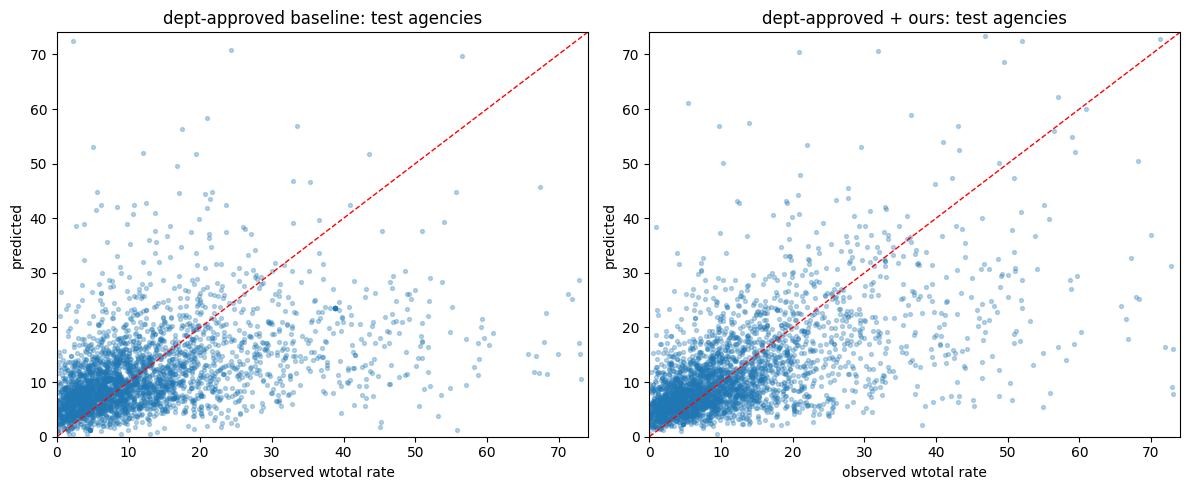

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, pred) in zip(axes, [("dept-approved baseline", pred_dept), ("dept-approved + ours", pred_dpo)]):
    obs = test_df["wtotal_pt_m"].values
    ax.scatter(obs, pred, s=8, alpha=0.3)
    lim = [0, np.nanpercentile(obs, 99)]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("observed wtotal rate"); ax.set_ylabel("predicted")
    ax.set_title(f"{label}: test agencies")
plt.tight_layout()

#### 6. Stepwise (forward) feature selection on **dept-approved + ours**

Greedy forward selection over our deployable set, scored by **population-weighted 5-fold CV R² on
the training agencies** (selection never touches the test set); a feature is kept only if it
improves CV R² by more than `TOL`. Held-out **test adjusted R²** is reported alongside as an honest
validation curve.

- **Phase 1 — our features:** forward-select from `ours_experiments` (our BG set, reshaped transit).
- **Phase 2 — dept-allowed add-ons:** holding Phase 1 fixed, forward-add the 6 Department-allowed
  predictors (`dept_nonredundant`). The combined pool is exactly the dept-approved + ours set.

In [16]:
from sklearn.model_selection import KFold

TOL = 0.001          # min CV-R² gain to keep adding a feature (tweak for more/less parsimony)
N_SPLITS = 5

def _weighted_cv_r2(preds, seed=0):
    if not preds:
        return float("-inf")
    X = train_df[preds].fillna(train_df[preds].median())
    y = train_df["wtotal_pt_m"].values
    w = train_df["population_m"].values
    oof = np.empty(len(y))
    for tr, va in KFold(n_splits=N_SPLITS, shuffle=True, random_state=seed).split(X):
        sc = StandardScaler().fit(X.iloc[tr])
        m = TransformedTargetRegressor(regressor=RidgeCV(), func=np.log1p, inverse_func=np.expm1)
        m.fit(sc.transform(X.iloc[tr]), y[tr], sample_weight=w[tr])
        oof[va] = m.predict(sc.transform(X.iloc[va]))
    return r2_score(y, oof, sample_weight=w)

def _test_fit(preds):
    med = train_df[preds].median()
    Xtr, Xte = train_df[preds].fillna(med), test_df[preds].fillna(med)
    sc = StandardScaler().fit(Xtr)
    ytr, yte = train_df["wtotal_pt_m"].values, test_df["wtotal_pt_m"].values
    wtr, wte = train_df["population_m"].values, test_df["population_m"].values
    m = TransformedTargetRegressor(regressor=RidgeCV(), func=np.log1p, inverse_func=np.expm1)
    m.fit(sc.transform(Xtr), ytr, sample_weight=wtr)
    pte = m.predict(sc.transform(Xte))
    r2 = r2_score(yte, pte, sample_weight=wte)
    return dict(R2_test=round(r2, 3),
                adjR2_test=round(adjusted_r2(r2, len(yte), len(preds)), 3),
                MAE_test=round(mean_absolute_error(yte, pte, sample_weight=wte), 3))

def forward_select(pool, base=None, tol=TOL):
    selected = list(base or [])
    remaining = [c for c in pool if c not in selected]
    best = _weighted_cv_r2(selected) if selected else float("-inf")
    hist = []
    while remaining:
        score, feat = max(((_weighted_cv_r2(selected + [c]), c) for c in remaining),
                          key=lambda t: t[0])
        if score - best < tol:
            break
        selected.append(feat); remaining.remove(feat)
        t = _test_fit(selected)
        hist.append(dict(step=len(selected) - len(base or []), added=feat,
                         cv_R2=round(score, 4), d_cv=round(score - best, 4),
                         test_adjR2=t["adjR2_test"], test_MAE=t["MAE_test"]))
        best = score
    return selected, pd.DataFrame(hist)

**Phase 1 — forward selection on our features (reshaped transit).**

In [17]:
our_selected, hist1 = forward_select(ours_experiments)
print(f"selected {len(our_selected)} of {len(ours_experiments)} our-predictors (reshaped transit):")
print(our_selected)
print("\n  full our-set    :", _test_fit(ours_experiments))
print("  stepwise our-set:", _test_fit(our_selected))
hist1

selected 10 of 22 our-predictors (reshaped transit):
['own_pct', 'vacant_pct_log', 'pop_est_5mile_log', 'clip_foreclosure_pct_log', 'roof_debris_pct_avg', 'pop_ch_1mile', 'vacant_pct_lag6_log', 'unq_gas_stations_clips', 'moved1yr_pct', 'has_transit']

  full our-set    : {'R2_test': 0.488, 'adjR2_test': 0.484, 'MAE_test': 6.101}


  stepwise our-set: {'R2_test': 0.232, 'adjR2_test': 0.23, 'MAE_test': 8.366}


,step,added,cv_R2,d_cv,test_adjR2,test_MAE
0,1,own_pct,0.2488,inf,-0.204,10.015
1,2,vacant_pct_log,0.3713,0.1225,0.268,8.221
2,3,pop_est_5mile_log,0.4191,0.0477,0.165,8.617
3,4,clip_foreclosure_pct_log,0.4474,0.0283,0.142,8.668
4,5,roof_debris_pct_avg,0.4559,0.0085,0.130,8.720
5,6,pop_ch_1mile,0.4618,0.0059,0.143,8.673
6,7,vacant_pct_lag6_log,0.4659,0.0041,0.092,8.833
7,8,unq_gas_stations_clips,0.4689,0.0031,0.132,8.694
8,9,moved1yr_pct,0.4714,0.0024,0.214,8.411
9,10,has_transit,0.4724,0.0010,0.230,8.366


**Phase 2 — forward-add the Department-allowed features on top of the Phase-1 set.**

In [18]:
combined, hist2 = forward_select(dept_nonredundant, base=our_selected)
added = [c for c in combined if c not in our_selected]
print(f"dept-allowed features added on top: {added}")
print("\n  stepwise our-set            :", _test_fit(our_selected))
print("  + dept-allowed stepwise adds:", _test_fit(combined))
hist2

dept-allowed features added on top: ['midatlantic', 'zin_household_pct', 'zlg10_jobs_5min', 'encentral']

  stepwise our-set            : {'R2_test': 0.232, 'adjR2_test': 0.23, 'MAE_test': 8.366}
  + dept-allowed stepwise adds: {'R2_test': 0.565, 'adjR2_test': 0.563, 'MAE_test': 5.879}


,step,added,cv_R2,d_cv,test_adjR2,test_MAE
0,1,midatlantic,0.4996,0.0272,0.544,6.136
1,2,zin_household_pct,0.5095,0.0098,0.551,6.085
2,3,zlg10_jobs_5min,0.5121,0.0027,0.556,6.066
3,4,encentral,0.5152,0.0031,0.563,5.879


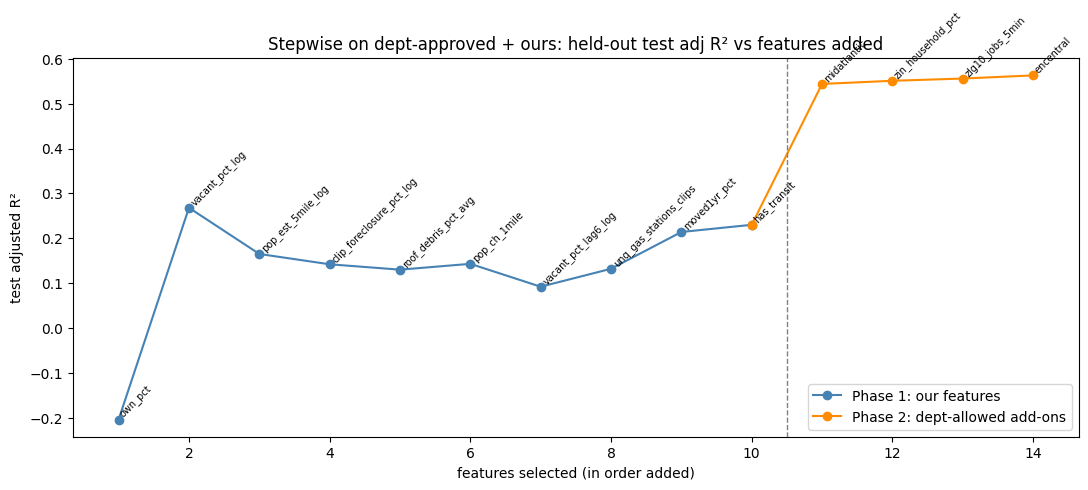

In [19]:
# validation curve: held-out test adjusted R² as features are added (phase 1 then phase 2)
p1 = hist1.assign(phase="our features")
p2 = hist2.assign(phase="dept-allowed add-ons")
traj = pd.concat([p1, p2], ignore_index=True)
traj["k"] = range(1, len(traj) + 1)

fig, ax = plt.subplots(figsize=(11, 5))
n1 = len(p1)
ax.plot(traj["k"][:n1], traj["test_adjR2"][:n1], "-o", color="steelblue", label="Phase 1: our features")
ax.plot(traj["k"][n1-1:], traj["test_adjR2"][n1-1:], "-o", color="darkorange", label="Phase 2: dept-allowed add-ons")
for _, r in traj.iterrows():
    ax.annotate(r["added"], (r["k"], r["test_adjR2"]), rotation=45,
                fontsize=7, ha="left", va="bottom")
ax.axvline(n1 + 0.5, color="grey", ls="--", lw=1)
ax.set_xlabel("features selected (in order added)"); ax.set_ylabel("test adjusted R²")
ax.set_title("Stepwise on dept-approved + ours: held-out test adj R\u00b2 vs features added")
ax.legend(loc="lower right"); plt.tight_layout()